In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
from processedata import Crop_df,Rain_df

India Crop Data and India Rain Fall Data  Proceed Sucessfully


In [2]:
Crop_df.shape

(16146, 80)

In [3]:
Crop_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16146 entries, 0 to 16145
Data columns (total 80 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   Dist_Code                                    16146 non-null  int64  
 1   Year                                         16146 non-null  int64  
 2   State_Code                                   16146 non-null  int64  
 3   State_Name                                   16146 non-null  object 
 4   Dist_Name                                    16146 non-null  object 
 5   RICE_AREA_(1000_ha)                          16146 non-null  float64
 6   RICE_PRODUCTION_(1000_tons)                  16146 non-null  float64
 7   RICE_YIELD_(Kg_per_ha)                       16146 non-null  float64
 8   WHEAT_AREA_(1000_ha)                         16146 non-null  float64
 9   WHEAT_PRODUCTION_(1000_tons)                 16146 non-null  float64
 10

In [4]:
Crop_df.isna().sum()

Dist_Code                               0
Year                                    0
State_Code                              0
State_Name                              0
Dist_Name                               0
                                       ..
VEGETABLES_AREA_(1000_ha)               0
FRUITS_AND_VEGETABLES_AREA_(1000_ha)    0
POTATOES_AREA_(1000_ha)                 0
ONION_AREA_(1000_ha)                    0
FODDER_AREA_(1000_ha)                   0
Length: 80, dtype: int64

In [5]:
Crop_df.duplicated().sum()

np.int64(0)

In [6]:
Crop_df

,Dist_Code,Year,State_Code,State_Name,Dist_Name,RICE_AREA_(1000_ha),RICE_PRODUCTION_(1000_tons),RICE_YIELD_(Kg_per_ha),WHEAT_AREA_(1000_ha),WHEAT_PRODUCTION_(1000_tons),...,SUGARCANE_YIELD_(Kg_per_ha),COTTON_AREA_(1000_ha),COTTON_PRODUCTION_(1000_tons),COTTON_YIELD_(Kg_per_ha),FRUITS_AREA_(1000_ha),VEGETABLES_AREA_(1000_ha),FRUITS_AND_VEGETABLES_AREA_(1000_ha),POTATOES_AREA_(1000_ha),ONION_AREA_(1000_ha),FODDER_AREA_(1000_ha)
0,1,1966,14,Chhattisgarh,Durg,548.00,185.00,337.59,44.00,20.00,...,1777.78,0.0,0.0,0.0,5.95,6.64,12.59,0.01,0.60,0.47
1,1,1967,14,Chhattisgarh,Durg,547.00,409.00,747.71,50.00,26.00,...,1500.00,0.0,0.0,0.0,5.77,7.24,13.02,0.01,0.56,1.23
2,1,1968,14,Chhattisgarh,Durg,556.30,468.00,841.27,53.70,30.00,...,1000.00,0.0,0.0,0.0,5.41,7.40,12.81,0.10,0.58,1.02
3,1,1969,14,Chhattisgarh,Durg,563.40,400.80,711.40,49.40,26.50,...,1900.00,0.0,0.0,0.0,5.52,7.16,12.69,0.01,0.56,0.84
4,1,1970,14,Chhattisgarh,Durg,571.60,473.60,828.55,44.20,29.00,...,2000.00,0.0,0.0,0.0,5.45,7.19,12.64,0.02,0.52,0.42
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16141,917,2013,15,Jharkhand,Singhbhum,267.06,579.70,2170.67,1.53,1.85,...,0.00,0.0,0.0,0.0,0.00,9.02,9.03,0.48,0.08,0.00
16142,917,2014,15,Jharkhand,Singhbhum,256.33,586.63,2288.57,5.36,6.65,...,0.00,0.0,0.0,0.0,0.00,8.63,8.64,0.46,0.04,0.00
16143,917,2015,15,Jharkhand,Singhbhum,263.21,264.71,1005.70,1.99,1.82,...,0.00,0.0,0.0,0.0,0.00,6.84,6.85,0.42,0.01,0.00
16144,917,2016,15,Jharkhand,Singhbhum,224.05,319.01,1423.84,0.38,0.83,...,0.00,0.0,0.0,0.0,0.03,6.40,6.43,0.03,0.01,0.00


## EDA

### Top 7 RICE PRODUCTION State Data(Bar_plot)

In [7]:
R_df = Crop_df[['State_Name','RICE_PRODUCTION_(1000_tons)']].groupby('State_Name').sum().sort_values(by='RICE_PRODUCTION_(1000_tons)',ascending=False).head(7).reset_index()
R_df

,State_Name,RICE_PRODUCTION_(1000_tons)
0,West Bengal,544232.26
1,Uttar Pradesh,445597.62
2,Punjab,335040.10
3,Andhra Pradesh,315185.40
4,Tamil Nadu,291201.51
5,Orissa,282532.93
6,Bihar,231759.00


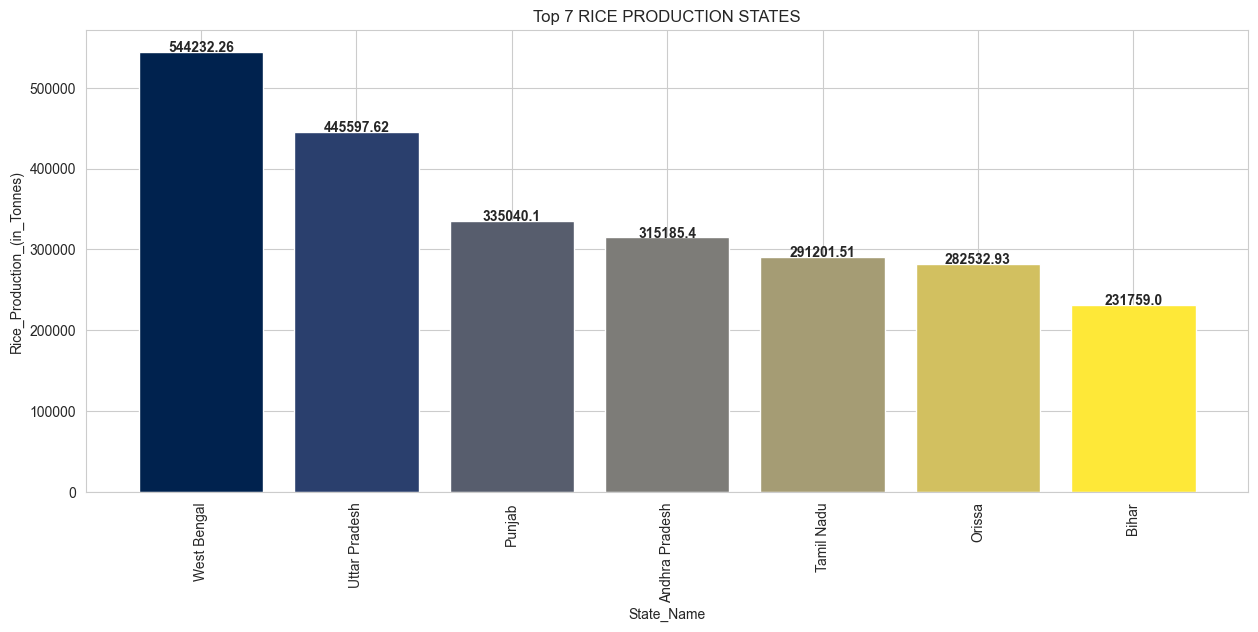

In [8]:
plt.figure(figsize=(15,6))
sns.set_style('whitegrid')
colors = plt.cm.cividis(np.linspace(0, 1, len(R_df)))
bars = plt.bar(R_df['State_Name'], R_df['RICE_PRODUCTION_(1000_tons)'],color = colors)
for i in range(len(bars)):
    plt.text(i,R_df['RICE_PRODUCTION_(1000_tons)'][i],R_df['RICE_PRODUCTION_(1000_tons)'][i], 
             ha = "center", fontweight = "bold", fontsize = 10)
plt.xlabel('State_Name')
plt.ylabel('Rice_Production_(in_Tonnes)')
plt.xticks(rotation=90)
plt.title('Top 7 RICE PRODUCTION STATES')
plt.show()

### Top 5 Wheat Producing States Data(Bar_chart)and its percentage(%)(Pie_chart)

In [9]:
W_df = Crop_df[['State_Name','WHEAT_PRODUCTION_(1000_tons)']].groupby('State_Name').sum().sort_values(by='WHEAT_PRODUCTION_(1000_tons)',ascending=False).reset_index().head(5)
W_df


,State_Name,WHEAT_PRODUCTION_(1000_tons)
0,Uttar Pradesh,970210.07
1,Punjab,593848.90
2,Haryana,348429.60
3,Madhya Pradesh,338644.25
4,Rajasthan,265994.99


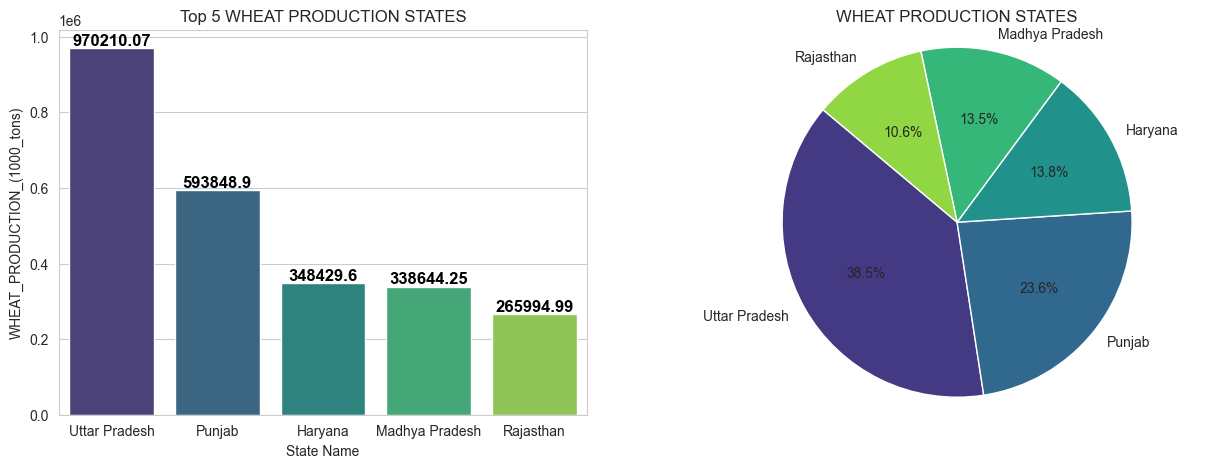

In [10]:
fig,axes=plt.subplots(1,2,figsize=(15,5))
sns.set_style('white')

sns.barplot(x='State_Name',y='WHEAT_PRODUCTION_(1000_tons)',data=W_df,ax=axes[0],palette='viridis')
for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height()}', 
                (p.get_x() + p.get_width() / 2, p.get_height()), 
                ha='center', va='bottom', fontsize=12, fontweight='bold', color='black')
axes[0].set_title('Top 5 WHEAT PRODUCTION STATES')
axes[0].set_xlabel('State Name')

plt.pie(W_df['WHEAT_PRODUCTION_(1000_tons)'], labels=W_df['State_Name'], autopct='%1.1f%%', startangle=140, colors=sns.color_palette("viridis", len(W_df)))
axes[1].set_title('WHEAT PRODUCTION STATES')
axes[1].axis('equal') 
plt.show()

### Oil seed production by top 5 states

In [11]:
O_df = Crop_df[['State_Name','OILSEEDS_AREA_(1000_ha)']].groupby('State_Name').sum().sort_values(by='OILSEEDS_AREA_(1000_ha)',ascending=False).reset_index().head(5)
O_df

,State_Name,OILSEEDS_AREA_(1000_ha)
0,Madhya Pradesh,189945.92
1,Rajasthan,142433.47
2,Maharashtra,134069.16
3,Gujarat,130724.71
4,Karnataka,92527.23


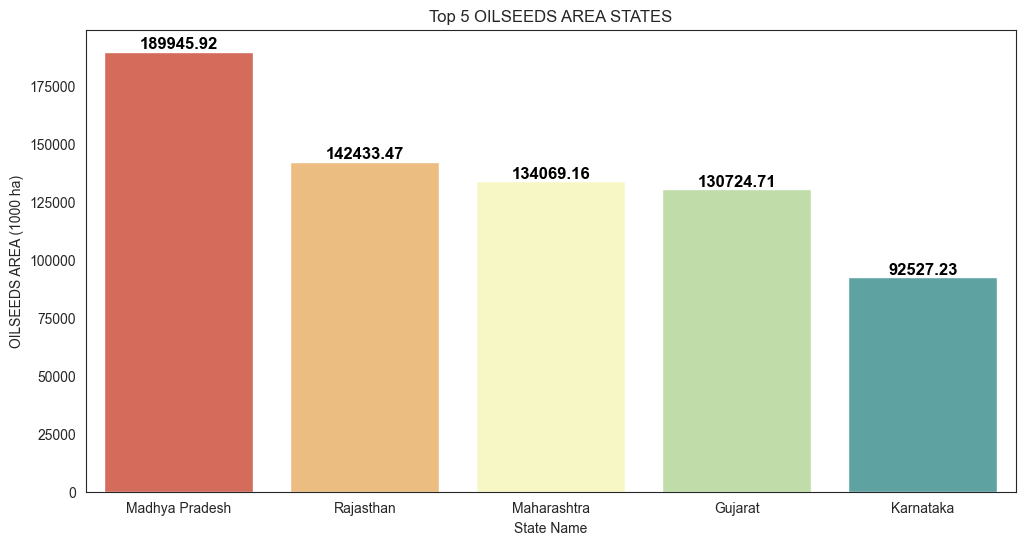

In [12]:
plt.figure(figsize=(12,6))
ax = sns.barplot(x='State_Name',y='OILSEEDS_AREA_(1000_ha)',data=O_df,palette='Spectral')
ax.set_title('Top 5 OILSEEDS AREA STATES')
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', 
                (p.get_x() + p.get_width() / 2, p.get_height()), 
                ha='center', va='bottom', fontsize=12, fontweight='bold', color='black')
plt.xlabel('State Name')
plt.ylabel('OILSEEDS AREA (1000 ha)')
plt.show()

### Top 7 SUNFLOWER PRODUCTION  State

In [13]:
S_df = Crop_df[['State_Name','SUNFLOWER_PRODUCTION_(1000_tons)']].groupby('State_Name').sum().sort_values(by='SUNFLOWER_PRODUCTION_(1000_tons)',ascending=False).reset_index().head(7)
S_df

,State_Name,SUNFLOWER_PRODUCTION_(1000_tons)
0,Karnataka,10785.87
1,Maharashtra,5599.46
2,Andhra Pradesh,4447.78
3,Telangana,1401.06
4,Punjab,1081.86
5,Tamil Nadu,762.38
6,Uttar Pradesh,552.66


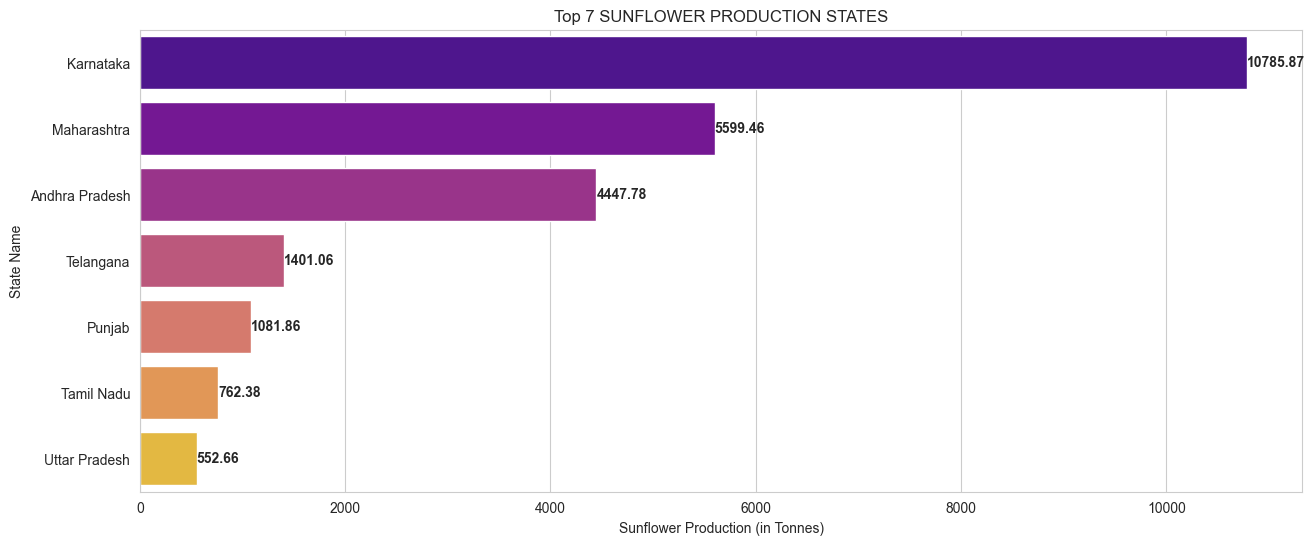

In [14]:
plt.figure(figsize=(15,6))
sns.set_style('whitegrid')
sns.barplot(x='SUNFLOWER_PRODUCTION_(1000_tons)',y='State_Name',data=S_df,palette='plasma',orient='h')
for i, v in enumerate(S_df['SUNFLOWER_PRODUCTION_(1000_tons)']):
    plt.text(v, i, str(v), va='center', fontweight='bold', fontsize=10)
plt.title('Top 7 SUNFLOWER PRODUCTION STATES')
plt.xlabel('Sunflower Production (in Tonnes)')
plt.ylabel('State Name')
plt.show()

### India's SUGARCANE PRODUCTION From Last 50 Years(Line_plot)

In [15]:
Su_df_year = Crop_df[['Year','SUGARCANE_PRODUCTION_(1000_tons)']].groupby('Year').sum().reset_index().sort_values(by='Year').tail(50)
Su_df_year

,Year,SUGARCANE_PRODUCTION_(1000_tons)
2,1968,12720.70
3,1969,13719.57
4,1970,12381.60
5,1971,11664.01
6,1972,12573.28
7,1973,14392.62
8,1974,14640.45
9,1975,14931.26
10,1976,15480.12
11,1977,18136.92


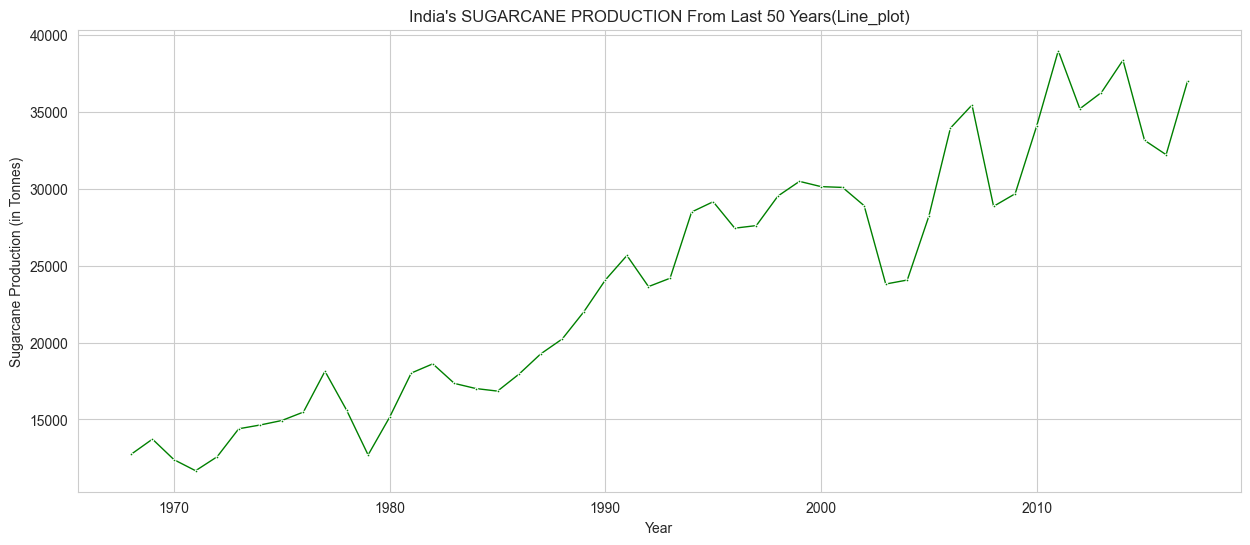

In [16]:
plt.figure(figsize=(15,6))
sns.set_style('whitegrid')
sns.lineplot(x='Year',y = 'SUGARCANE_PRODUCTION_(1000_tons)',data=Su_df_year,color='green',marker='o',linewidth=1,markersize=2)
plt.title('India\'s SUGARCANE PRODUCTION From Last 50 Years(Line_plot)')
plt.xlabel('Year') 
plt.ylabel('Sugarcane Production (in Tonnes)')
plt.show()

### Rice Production Vs Wheat Production (Last 50y)

In [17]:
R_W_df_year = Crop_df[['Year','RICE_PRODUCTION_(1000_tons)','WHEAT_PRODUCTION_(1000_tons)']].groupby('Year').sum().sort_values(by='Year').tail(50).reset_index()
R_W_df_year

,Year,RICE_PRODUCTION_(1000_tons),WHEAT_PRODUCTION_(1000_tons)
0,1968,34701.52,17375.67
1,1969,35836.01,19232.36
2,1970,39324.12,22677.88
3,1971,39946.79,25280.89
4,1972,37925.93,22879.56
5,1973,42026.94,20833.39
6,1974,37690.51,23052.96
7,1975,46144.36,27150.41
8,1976,40226.45,27580.73
9,1977,50439.41,30003.66


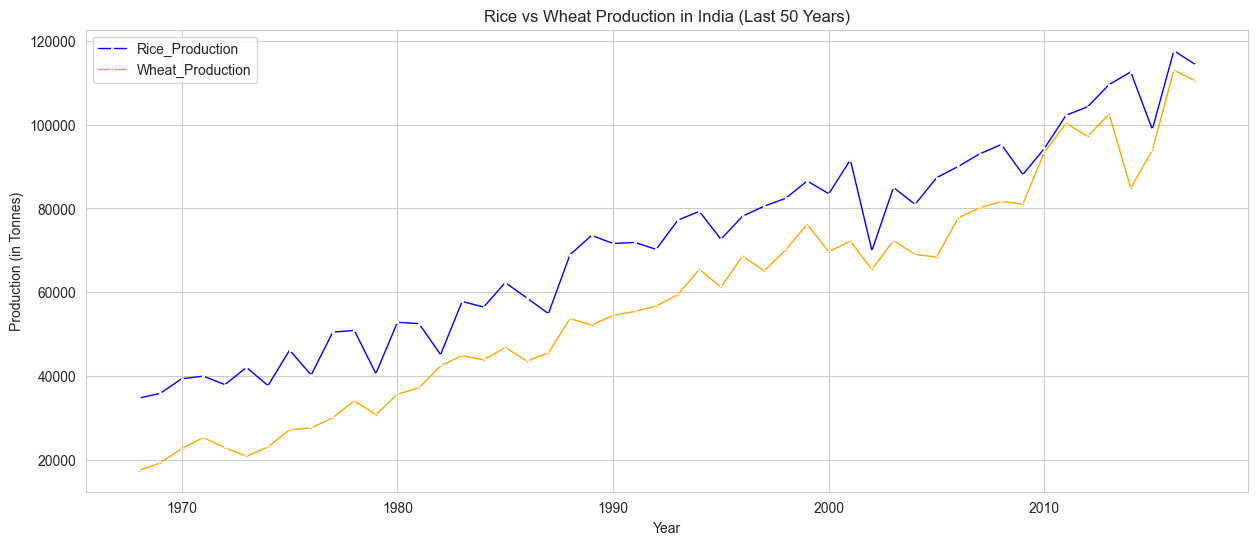

In [18]:
plt.figure(figsize=(15,6))
sns.set_style('whitegrid')
sns.lineplot(x='Year', y='RICE_PRODUCTION_(1000_tons)', data=R_W_df_year, color='blue', marker='*', linewidth=1, markersize=2, label='Rice_Production')
sns.lineplot(x='Year', y='WHEAT_PRODUCTION_(1000_tons)', data=R_W_df_year, color='orange', marker='o', linewidth=1, markersize=2, label='Wheat_Production')
plt.title('Rice vs Wheat Production in India (Last 50 Years)') 
plt.xlabel('Year')
plt.ylabel('Production (in Tonnes)')
plt.legend(loc='upper left')
plt.show()

### Rice Production By West Bengal Districts

In [19]:
R_WB_df = Crop_df[Crop_df['State_Name'] == 'West Bengal'][['Dist_Name','RICE_PRODUCTION_(1000_tons)']].groupby('Dist_Name').sum().sort_values(by='RICE_PRODUCTION_(1000_tons)', ascending=False).reset_index()
R_WB_df

,Dist_Name,RICE_PRODUCTION_(1000_tons)
0,Midnapur,98868.28
1,Burdwan,71422.15
2,24 Parganas,63011.99
3,Birbhum,42213.81
4,Bankura,40165.20
5,Murshidabad,37261.24
6,West Dinajpur,35224.87
7,Hooghly,30962.21
8,Nadia,28016.30
9,Purulia,23147.50


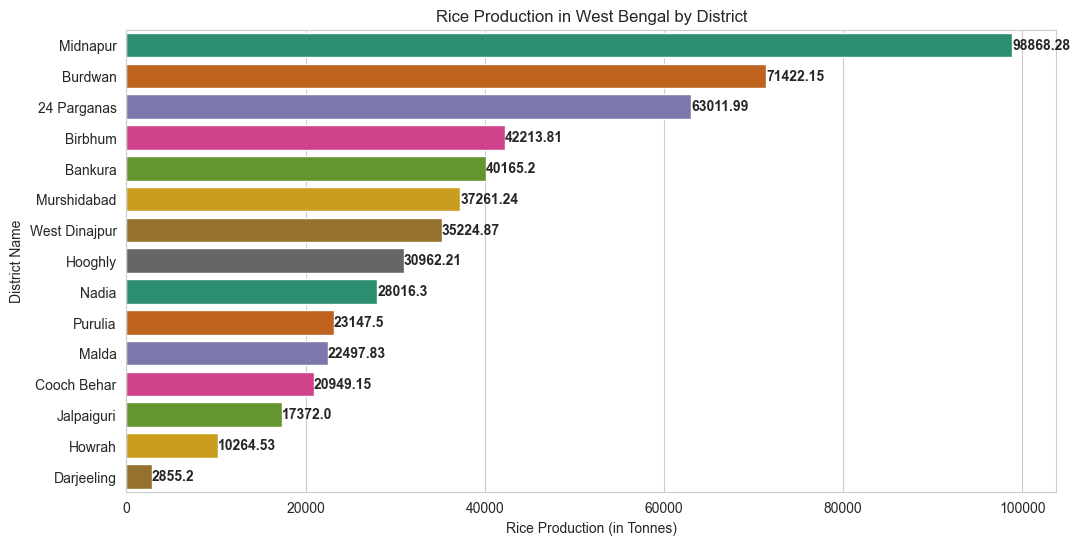

In [20]:
plt.figure(figsize=(12,6))
sns.barplot(x='RICE_PRODUCTION_(1000_tons)', y='Dist_Name', data=R_WB_df, palette='Dark2', orient='h')
for i, v in enumerate(R_WB_df['RICE_PRODUCTION_(1000_tons)']):
    plt.text(v, i, str(v), va='center', fontweight='bold', fontsize=10)
plt.title('Rice Production in West Bengal by District')
plt.xlabel('Rice Production (in Tonnes)')
plt.ylabel('District Name')
plt.show()

### Top 10 Wheat Production Years From UP

In [21]:
W_UP_df_year = pd.DataFrame(Crop_df.pivot_table(index='Year', columns='State_Name', values='WHEAT_PRODUCTION_(1000_tons)', aggfunc='sum')['Uttar Pradesh'].sort_values(ascending=False).head(10)).reset_index()
W_UP_df_year

,Year,Uttar Pradesh
0,2017,35798.60
1,2016,35120.90
2,2011,32271.69
3,2013,31611.63
4,2010,30602.91
5,2008,29110.93
6,2012,29041.28
7,2009,27910.80
8,2015,27010.39
9,2003,26445.45


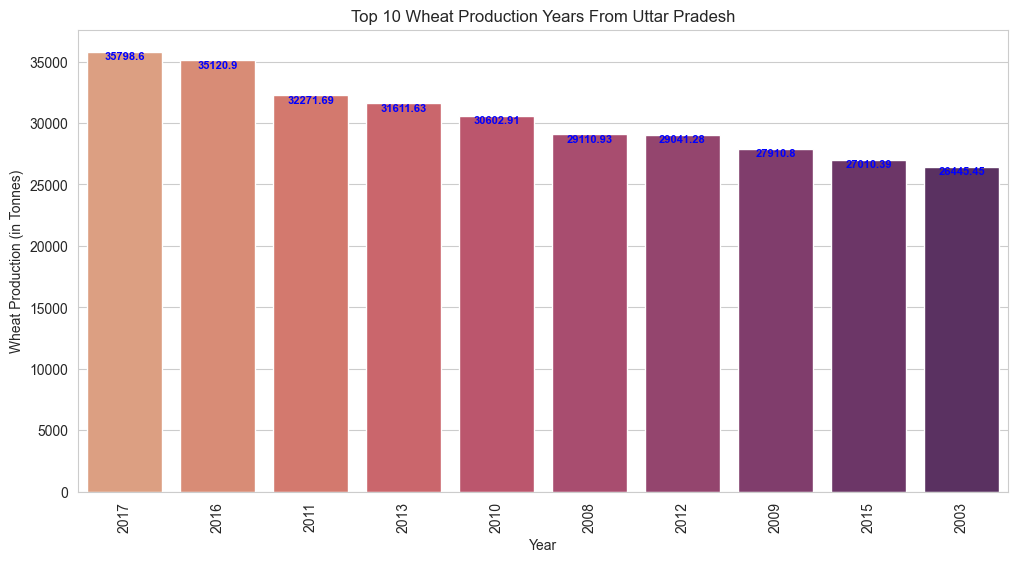

In [22]:
plt.figure(figsize=(12,6))
sns.barplot(x='Year', y='Uttar Pradesh', data=W_UP_df_year, palette='flare',order=W_UP_df_year['Year'].value_counts().index)
plt.xticks(rotation=90)
for i, v in enumerate(W_UP_df_year['Uttar Pradesh']):
    plt.text(i, v, str(v), ha='center', va='top', fontweight='bold',color='blue', fontsize=8)
plt.title('Top 10 Wheat Production Years From Uttar Pradesh')
plt.xlabel('Year')
plt.ylabel('Wheat Production (in Tonnes)')
plt.show()

### Millet Production (Last 50y)

In [23]:
M_df_year =Crop_df[['Year','SORGHUM_PRODUCTION_(1000_tons)', 'PEARL_MILLET_PRODUCTION_(1000_tons)', 'FINGER_MILLET_PRODUCTION_(1000_tons)']].groupby('Year').sum().sort_values(by='Year').tail(50).reset_index()
M_df_year

,Year,SORGHUM_PRODUCTION_(1000_tons),PEARL_MILLET_PRODUCTION_(1000_tons),FINGER_MILLET_PRODUCTION_(1000_tons)
0,1968,9312.97,3853.45,1528.89
1,1969,8980.01,5516.42,1659.85
2,1970,8084.65,8018.16,1879.32
3,1971,7747.21,5250.84,2006.80
4,1972,6753.39,3935.34,1695.74
5,1973,9015.36,7266.05,1879.76
6,1974,10203.77,3388.46,2027.00
7,1975,9462.24,5625.08,2652.48
8,1976,10381.13,5631.29,1981.01
9,1977,11683.67,4722.99,3000.37


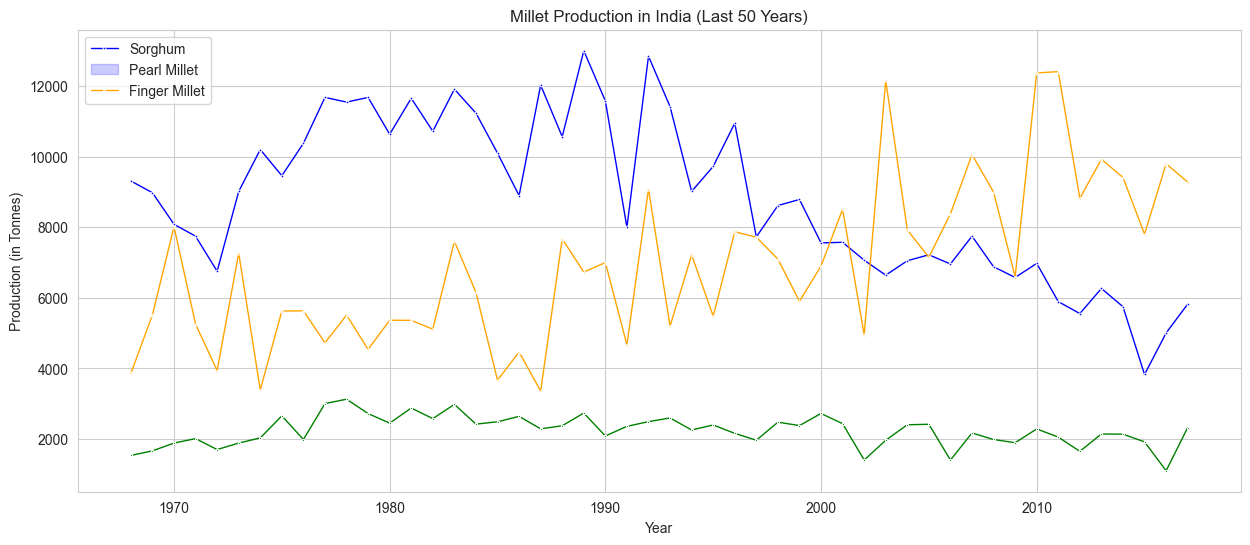

In [24]:
plt.figure(figsize=(15,6))
sns.set_style('whitegrid')
sns.lineplot(x='Year',y='SORGHUM_PRODUCTION_(1000_tons)',data=M_df_year, color='blue', marker='o', linewidth=1, markersize=2)
sns.lineplot(x='Year',y='PEARL_MILLET_PRODUCTION_(1000_tons)',data=M_df_year, color='orange', marker='^', linewidth=1, markersize=2)
sns.lineplot(x='Year',y='FINGER_MILLET_PRODUCTION_(1000_tons)',data=M_df_year, color='green', marker='s', linewidth=1, markersize=2)
plt.title('Millet Production in India (Last 50 Years)')
plt.xlabel('Year')
plt.ylabel('Production (in Tonnes)')
plt.legend(['Sorghum', 'Pearl Millet', 'Finger Millet'], loc='upper left')
plt.show()

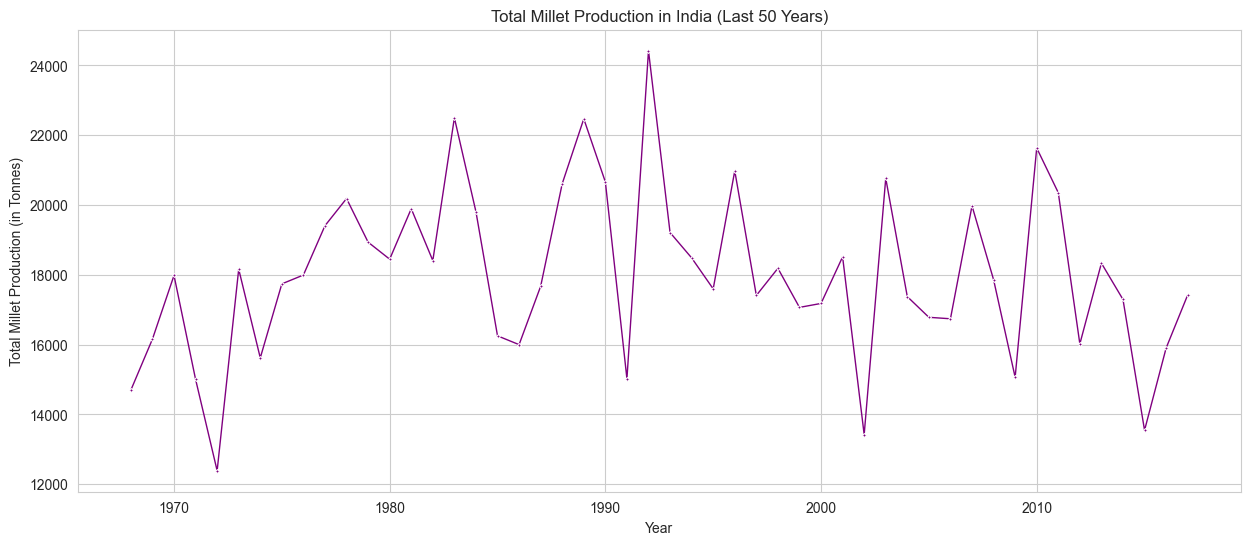

In [25]:
M_df_year['Total_Millet_Production'] = M_df_year['SORGHUM_PRODUCTION_(1000_tons)'] + M_df_year['PEARL_MILLET_PRODUCTION_(1000_tons)'] + M_df_year['FINGER_MILLET_PRODUCTION_(1000_tons)']
plt.figure(figsize=(15,6))
sns.set_style('whitegrid')
sns.lineplot(x='Year', y='Total_Millet_Production', data=M_df_year, color='purple', marker='D', linewidth=1, markersize=2)
plt.title('Total Millet Production in India (Last 50 Years)')
plt.xlabel('Year')
plt.ylabel('Total Millet Production (in Tonnes)')
plt.show()

### Sorghum Production (Kharif and Rabi) by Region

In [26]:
Sor_df = Crop_df[['SORGHUM_PRODUCTION_(1000_tons)','State_Name']].groupby('State_Name').sum().sort_values(by='SORGHUM_PRODUCTION_(1000_tons)', ascending=False).reset_index()
Sor_df

,State_Name,SORGHUM_PRODUCTION_(1000_tons)
0,Maharashtra,202055.20
1,Karnataka,77948.62
2,Madhya Pradesh,56882.48
3,Telangana,25786.24
4,Tamil Nadu,23882.24
5,Uttar Pradesh,18747.67
6,Andhra Pradesh,17582.51
7,Rajasthan,16892.86
8,Gujarat,16502.39
9,Haryana,1783.00


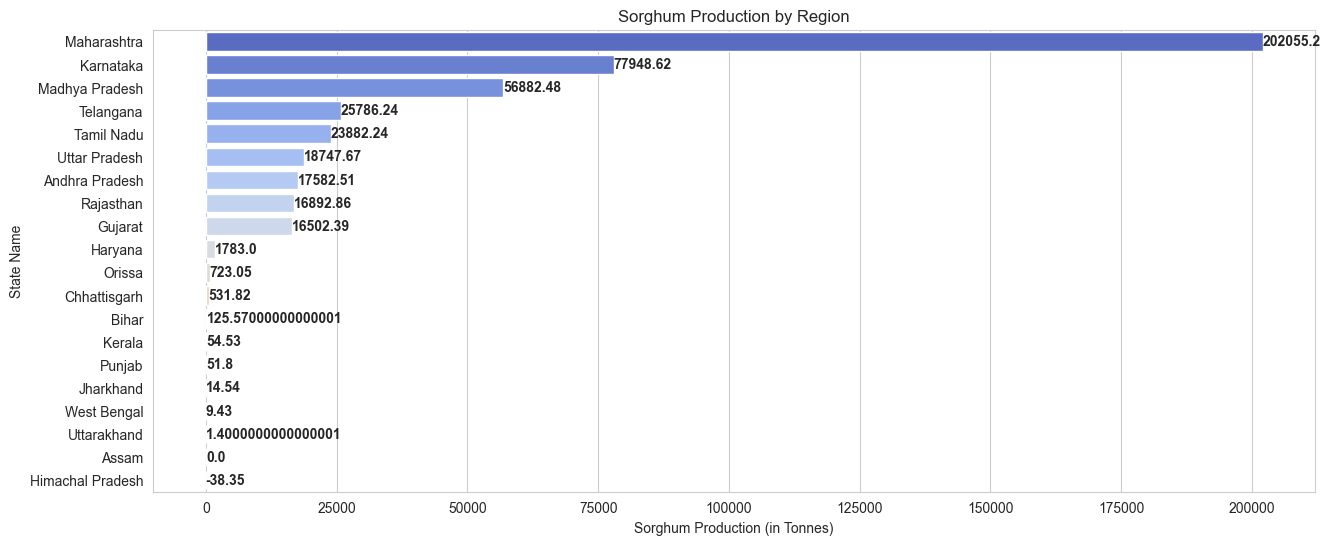

In [27]:
plt.figure(figsize=(15,6))
sns.set_style('whitegrid')
sns.barplot(x='SORGHUM_PRODUCTION_(1000_tons)', y='State_Name', data=Sor_df, palette='coolwarm', orient='h')
for i, v in enumerate(Sor_df['SORGHUM_PRODUCTION_(1000_tons)']):
    plt.text(v, i, str(v), va='center', fontweight='bold', fontsize=10)
plt.title('Sorghum Production by Region')
plt.xlabel('Sorghum Production (in Tonnes)')
plt.ylabel('State Name')
plt.show()

### Top 7 States for Groundnut Production

In [28]:
G_df = Crop_df[['State_Name','GROUNDNUT_PRODUCTION_(1000_tons)']].groupby('State_Name').sum().sort_values(by='GROUNDNUT_PRODUCTION_(1000_tons)', ascending=False).head(7).reset_index()
G_df

,State_Name,GROUNDNUT_PRODUCTION_(1000_tons)
0,Gujarat,98321.42
1,Andhra Pradesh,57844.81
2,Tamil Nadu,57662.42
3,Karnataka,36033.05
4,Maharashtra,29002.06
5,Rajasthan,17354.29
6,Orissa,16857.48


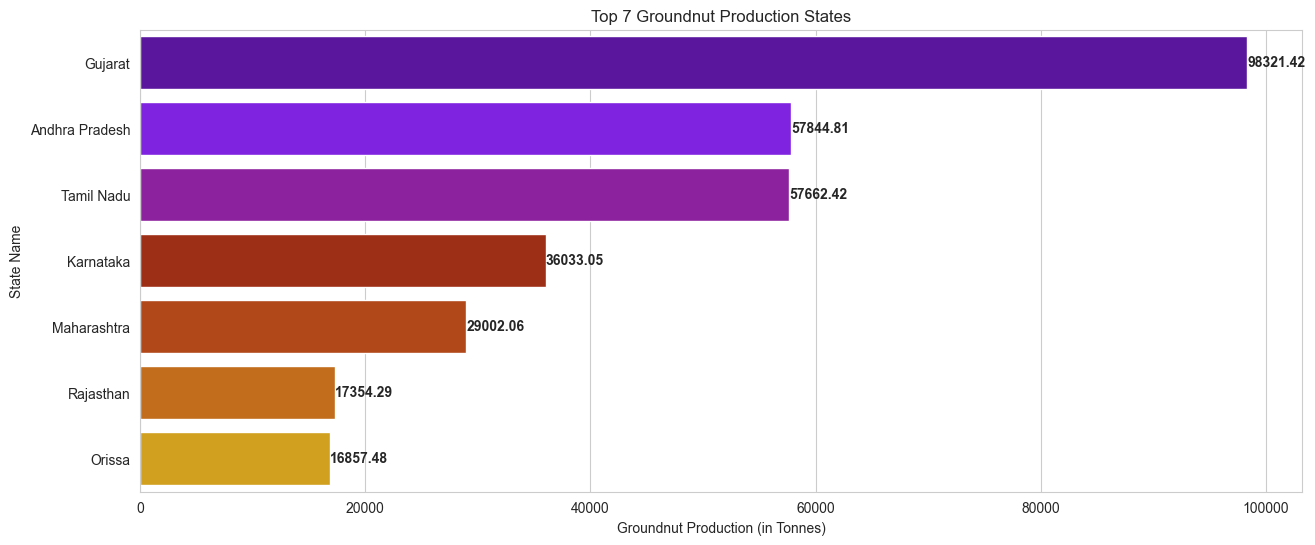

In [29]:
plt.figure(figsize=(15,6))
sns.set_style('whitegrid')
sns.barplot(x='GROUNDNUT_PRODUCTION_(1000_tons)', y='State_Name', data=G_df, palette='gnuplot')
for i, v in enumerate(G_df['GROUNDNUT_PRODUCTION_(1000_tons)']):
    plt.text(v, i, str(v), va='center', fontweight='bold', fontsize=10)
plt.title('Top 7 Groundnut Production States')
plt.xlabel('Groundnut Production (in Tonnes)')
plt.ylabel('State Name')
plt.show()

In [30]:
Soys_df_Pr_Ye = Crop_df[['State_Name','SOYABEAN_PRODUCTION_(1000_tons)','SOYABEAN_YIELD_(Kg_per_ha)']].groupby('State_Name').sum().sort_values(by='SOYABEAN_PRODUCTION_(1000_tons)', ascending=False).head(5).reset_index()
Soys_df_Pr_Ye

,State_Name,SOYABEAN_PRODUCTION_(1000_tons),SOYABEAN_YIELD_(Kg_per_ha)
0,Madhya Pradesh,136006.52,1161169.25
1,Maharashtra,58643.93,770938.60
2,Rajasthan,21174.99,404598.94
3,Telangana,3022.13,119230.77
4,Karnataka,2873.98,201773.29


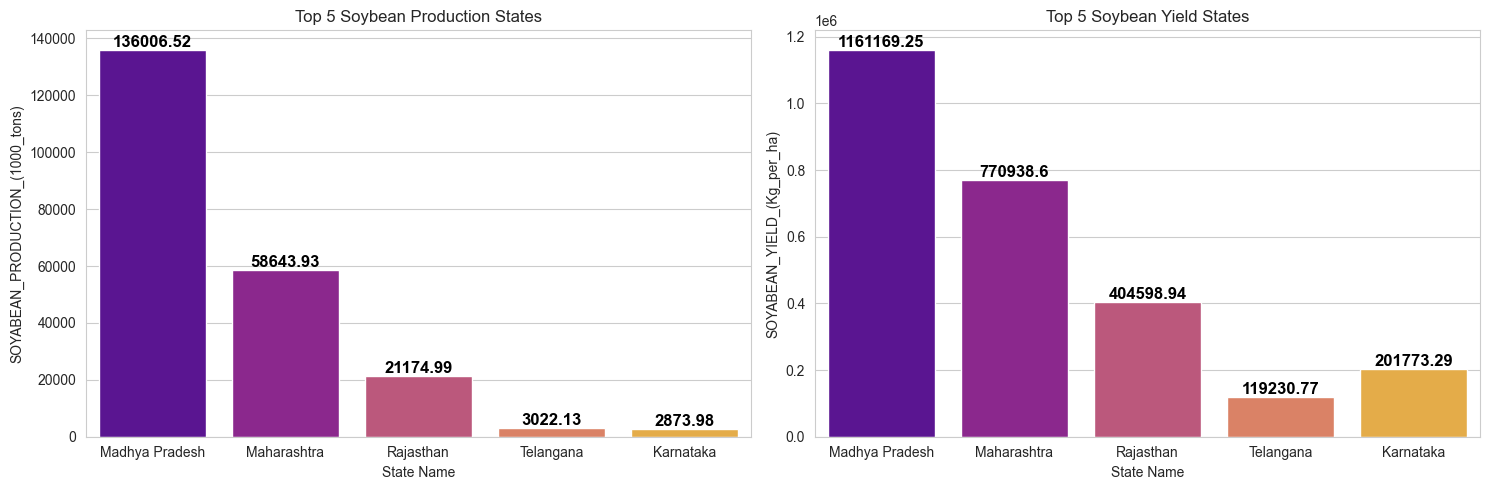

In [31]:
fig,axes=plt.subplots(1,2,figsize=(15,5))
sns.set_style('white')
sns.barplot(x='State_Name', y='SOYABEAN_PRODUCTION_(1000_tons)', data=Soys_df_Pr_Ye, ax=axes[0], palette='plasma')
for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height()}', 
                (p.get_x() + p.get_width() / 2, p.get_height()), 
                ha='center', va='bottom', fontsize=12, fontweight='bold', color='black')
axes[0].set_title('Top 5 Soybean Production States')
axes[0].set_xlabel('State Name')

sns.barplot(x='State_Name', y='SOYABEAN_YIELD_(Kg_per_ha)', data=Soys_df_Pr_Ye, ax=axes[1], palette='plasma')
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height()}', 
                (p.get_x() + p.get_width() / 2, p.get_height()), 
                ha='center', va='bottom', fontsize=12, fontweight='bold', color='black')
axes[1].set_title('Top 5 Soybean Yield States')
axes[1].set_xlabel('State Name')
plt.tight_layout()
plt.show()

### Oilseed Production in Major States

In [32]:
Oil_df = Crop_df.pivot_table(index='State_Name',values='OILSEEDS_PRODUCTION_(1000_tons)', aggfunc='sum').sort_values(by='OILSEEDS_PRODUCTION_(1000_tons)', ascending=False).head(5).reset_index()
Oil_df

,State_Name,OILSEEDS_PRODUCTION_(1000_tons)
0,Madhya Pradesh,153594.79
1,Gujarat,126224.01
2,Rajasthan,122726.86
3,Maharashtra,95567.91
4,Andhra Pradesh,76888.09


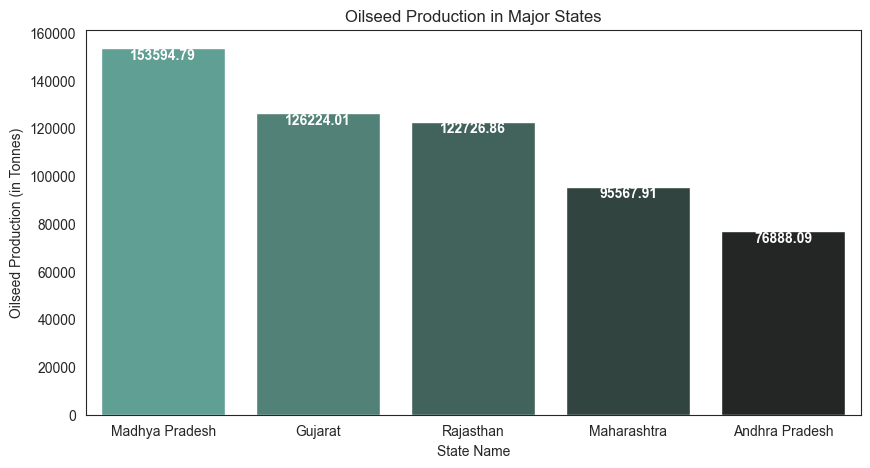

In [33]:
plt.figure(figsize=(10, 5))
sns.barplot(x='State_Name', y='OILSEEDS_PRODUCTION_(1000_tons)', data=Oil_df, palette='dark:#5A9_r')
for i, v in enumerate(Oil_df['OILSEEDS_PRODUCTION_(1000_tons)']):
    plt.text(i, v, str(v), ha='center', va='top', fontweight='bold', fontsize=10, color='white')
plt.title('Oilseed Production in Major States')
plt.xlabel('State Name')
plt.ylabel('Oilseed Production (in Tonnes)')
plt.show()

### Impact of Area Cultivated on Production (Rice, Wheat, Maize)

In [34]:
IA_df = Crop_df[['State_Name','RICE_PRODUCTION_(1000_tons)','WHEAT_PRODUCTION_(1000_tons)','MAIZE_PRODUCTION_(1000_tons)']].groupby('State_Name').sum().reset_index()
IA_df

,State_Name,RICE_PRODUCTION_(1000_tons),WHEAT_PRODUCTION_(1000_tons),MAIZE_PRODUCTION_(1000_tons)
0,Andhra Pradesh,315185.40,60.46,25242.65
1,Assam,165205.95,3854.11,999.71
2,Bihar,231759.00,176250.30,67137.23
3,Chhattisgarh,208208.22,4438.92,6999.24
4,Gujarat,48713.35,85537.63,24555.53
5,Haryana,107664.90,348429.60,3625.20
6,Himachal Pradesh,5426.01,22120.16,28075.97
7,Jharkhand,76435.78,3922.80,7296.77
8,Karnataka,146921.56,9715.78,75586.69
9,Kerala,49567.07,0.00,0.70


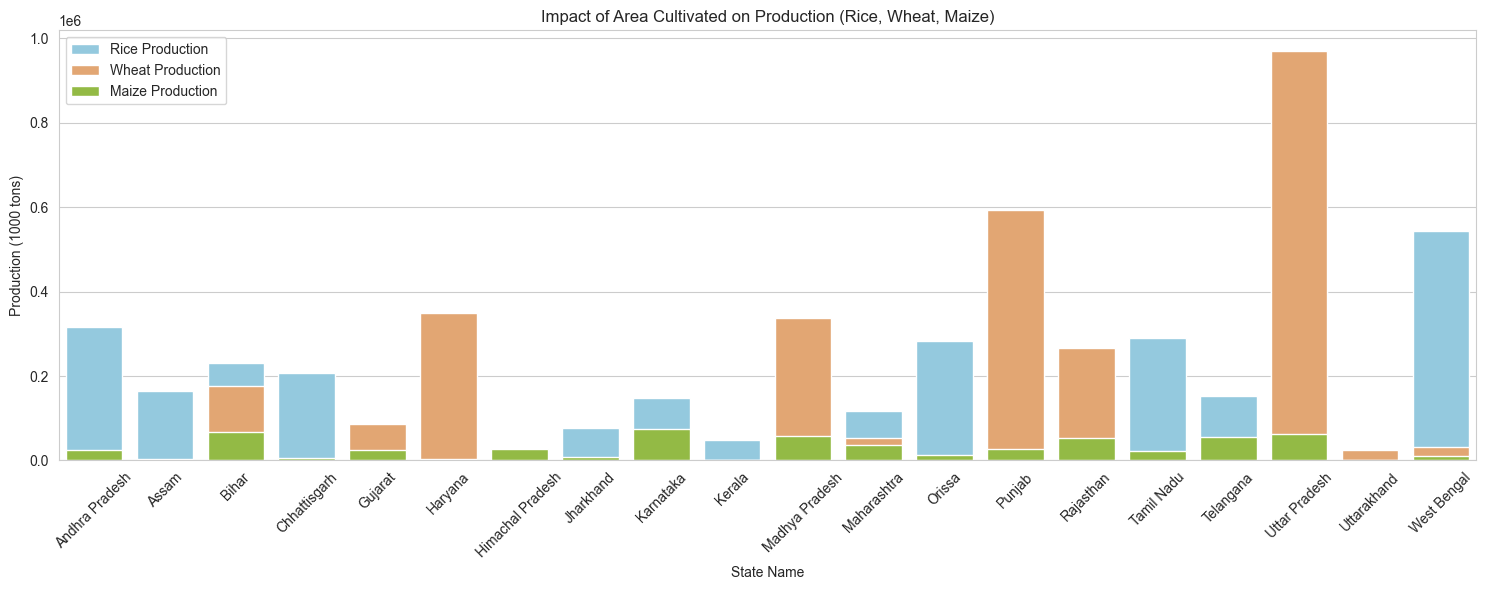

In [35]:
plt.figure(figsize=(15,6))
sns.set_style('whitegrid')

sns.barplot(x='State_Name', y='RICE_PRODUCTION_(1000_tons)', data=IA_df, color='skyblue', label='Rice Production')
sns.barplot(x='State_Name', y='WHEAT_PRODUCTION_(1000_tons)', data=IA_df, color='sandybrown', label='Wheat Production')
sns.barplot(x='State_Name', y='MAIZE_PRODUCTION_(1000_tons)', data=IA_df, color='yellowgreen', label='Maize Production')

plt.title('Impact of Area Cultivated on Production (Rice, Wheat, Maize)')
plt.xlabel('State Name')
plt.xticks(rotation=45)
plt.ylabel('Production (1000 tons)')
plt.legend()
plt.tight_layout()
plt.show()

### Rice vs. Wheat Yield Across States

In [36]:
R_W_df = Crop_df[['State_Name','RICE_YIELD_(Kg_per_ha)','WHEAT_YIELD_(Kg_per_ha)']].groupby('State_Name').sum().reset_index()
R_W_df

,State_Name,RICE_YIELD_(Kg_per_ha),WHEAT_YIELD_(Kg_per_ha)
0,Andhra Pradesh,1337079.18,116956.69
1,Assam,708457.90,558080.41
2,Bihar,730287.40,992099.68
3,Chhattisgarh,335014.04,311869.75
4,Gujarat,989691.47,1991362.26
5,Haryana,796460.55,1161151.95
6,Himachal Pradesh,574244.15,630164.41
7,Jharkhand,346166.10,349397.48
8,Karnataka,2125721.28,566556.69
9,Kerala,995867.63,4000.00


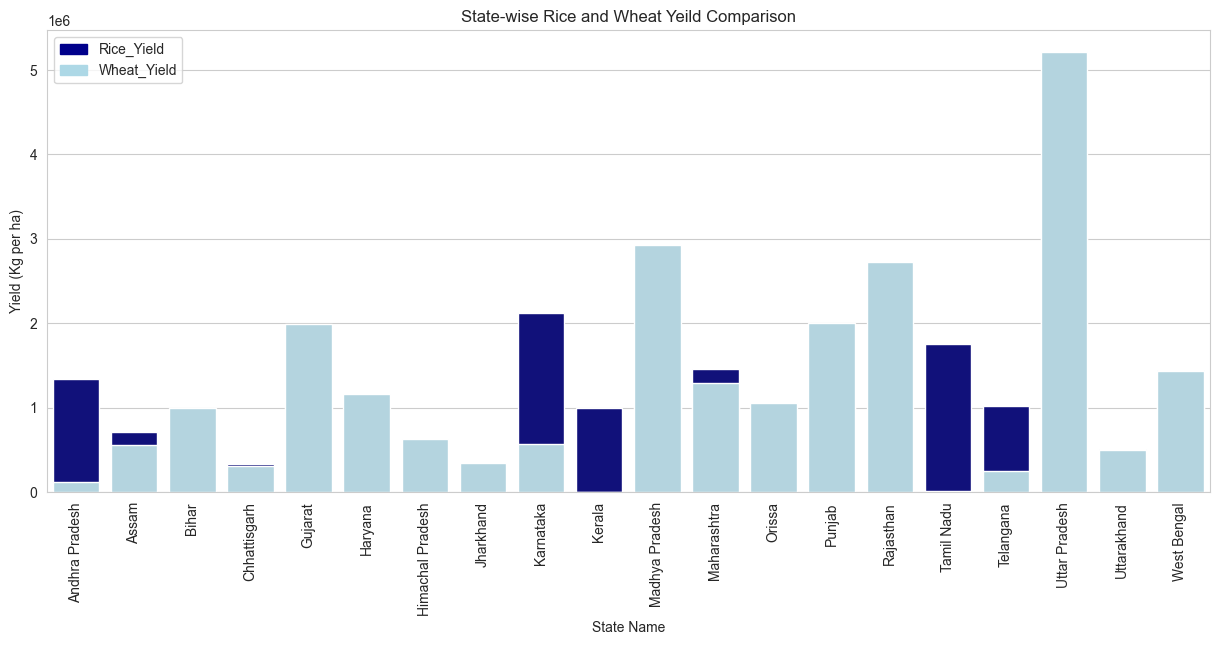

In [37]:
import matplotlib.patches as mpatches
plt.figure(figsize=(15,6))

bar1 = sns.barplot(x='State_Name', y='RICE_YIELD_(Kg_per_ha)', data=R_W_df, color='darkblue')

bar2 = sns.barplot(x='State_Name', y='WHEAT_YIELD_(Kg_per_ha)', data=R_W_df, color='lightblue')

# Legends
top_bar = mpatches.Patch(color='darkblue', label='Rice_Yield')
bottom_bar = mpatches.Patch(color='lightblue', label='Wheat_Yield')
plt.legend(handles=[top_bar, bottom_bar])

plt.xticks(rotation=90)
plt.title('State-wise Rice and Wheat Yeild Comparison')
plt.xlabel('State Name')
plt.ylabel('Yield (Kg per ha)')
plt.show()

In [38]:
Area_columns = [col for col in Crop_df.columns if 'AREA_(1000_ha)' in col]
Production_columns = [col for col in Crop_df.columns if 'PRODUCTION_(1000_tons)' in col]
Yield_columns = [col for col in Crop_df.columns if 'YIELD_(Kg_per_ha)' in col]

In [39]:
Area_df_year = Crop_df[['Year', *Area_columns]]

Area_df_year.pivot_table(index=Area_columns, values='Year', aggfunc='sum')

Area_df_year['Total_Area'] = Area_df_year[Area_columns].sum(axis=1)

Production_df_year = Crop_df[['Year', *Production_columns]].pivot_table(index='Year', values=Production_columns, aggfunc='sum')
Production_df_year['Total_Production'] = Production_df_year[Production_columns].sum(axis=1)


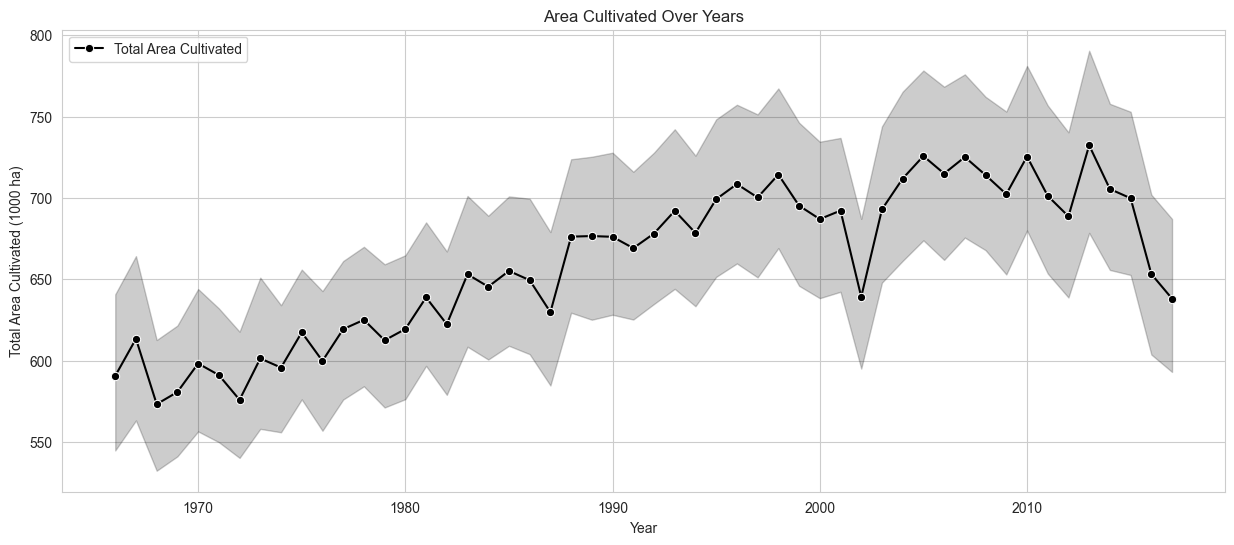

In [40]:
plt.figure(figsize=(15,6))
sns.set_style('whitegrid')
sns.lineplot(data=Area_df_year,x='Year',y='Total_Area',color='black',marker='o',label='Total Area Cultivated')
plt.title('Area Cultivated Over Years')
plt.xlabel('Year')
plt.ylabel('Total Area Cultivated (1000 ha)')
plt.show()

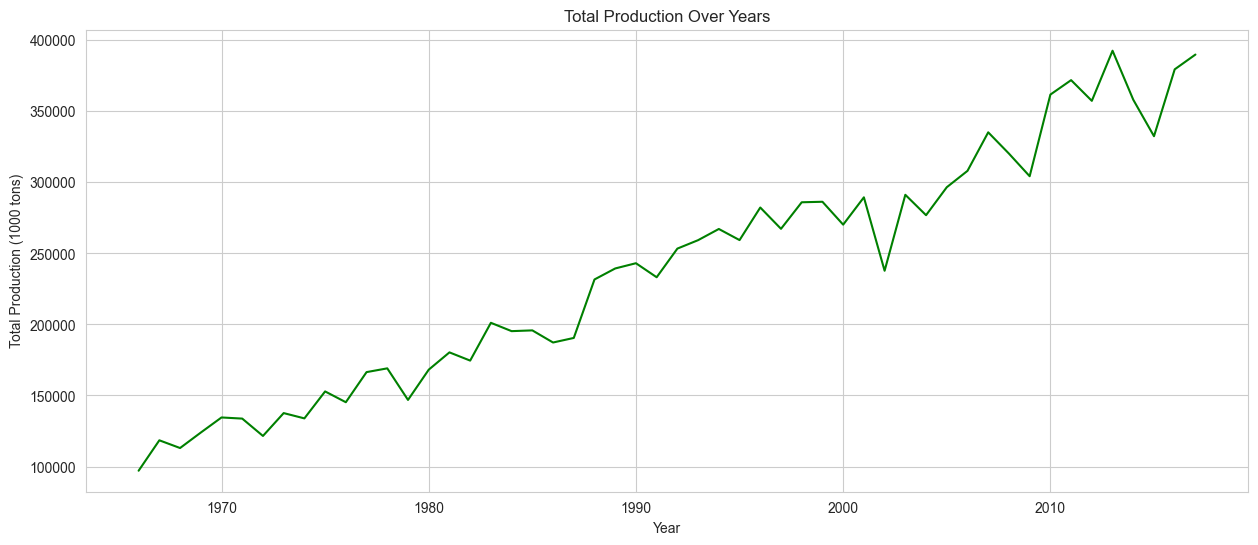

In [41]:
plt.figure(figsize=(15,6))
sns.set_style('whitegrid')
sns.lineplot(data=Production_df_year, x='Year', y='Total_Production', color='green')
plt.title('Total Production Over Years')
plt.xlabel('Year')
plt.ylabel('Total Production (1000 tons)')
plt.show()

In [42]:
Avg_yeild_df = Crop_df[['Year',*Yield_columns]].pivot_table(index='Year',values=Yield_columns,aggfunc='mean')
Avg_yeild_df.head()

,BARLEY_YIELD_(Kg_per_ha),CASTOR_YIELD_(Kg_per_ha),CHICKPEA_YIELD_(Kg_per_ha),COTTON_YIELD_(Kg_per_ha),FINGER_MILLET_YIELD_(Kg_per_ha),GROUNDNUT_YIELD_(Kg_per_ha),KHARIF_SORGHUM_YIELD_(Kg_per_ha),LINSEED_YIELD_(Kg_per_ha),MAIZE_YIELD_(Kg_per_ha),MINOR_PULSES_YIELD_(Kg_per_ha),...,RABI_SORGHUM_YIELD_(Kg_per_ha),RAPESEED_AND_MUSTARD_YIELD_(Kg_per_ha),RICE_YIELD_(Kg_per_ha),SAFFLOWER_YIELD_(Kg_per_ha),SESAMUM_YIELD_(Kg_per_ha),SORGHUM_YIELD_(Kg_per_ha),SOYABEAN_YIELD_(Kg_per_ha),SUGARCANE_YIELD_(Kg_per_ha),SUNFLOWER_YIELD_(Kg_per_ha),WHEAT_YIELD_(Kg_per_ha)
Year,,,,,,,,,,,,,,,,,,,,,
1966,361.969355,70.792548,347.795903,74.179161,277.858774,449.127548,375.088806,72.156645,734.266355,140.533161,...,134.519710,197.225968,744.699806,30.947032,174.953710,378.382548,-0.032258,3491.279065,17.070839,595.219419
1967,508.508484,94.750194,485.133032,76.445194,333.436000,556.468968,438.694484,100.587903,869.540323,155.929710,...,142.226484,251.074290,868.111000,37.144742,203.805032,442.372387,-0.032258,3690.415548,1.043000,736.596774
1968,392.964161,110.567129,477.393161,76.994258,288.096032,463.623968,427.877258,81.303419,709.261774,133.363774,...,174.816742,245.519129,821.167613,29.312129,184.704581,428.678548,-0.032258,3936.731774,6.634387,762.032710
1969,440.877065,111.017710,478.613806,71.684968,293.186129,528.131903,432.960774,96.046290,781.476645,206.431129,...,194.813742,262.676871,875.865742,24.125548,204.760032,433.845387,-0.032258,3786.528774,26.807516,808.584290
1970,509.039582,144.168617,537.668489,74.075113,347.141190,599.749003,457.766077,102.481222,1094.176206,211.469678,...,132.223505,310.180000,1010.847492,29.129003,203.315627,442.070257,3.887974,3926.294244,4.280193,946.365338


### Cmap Visualization

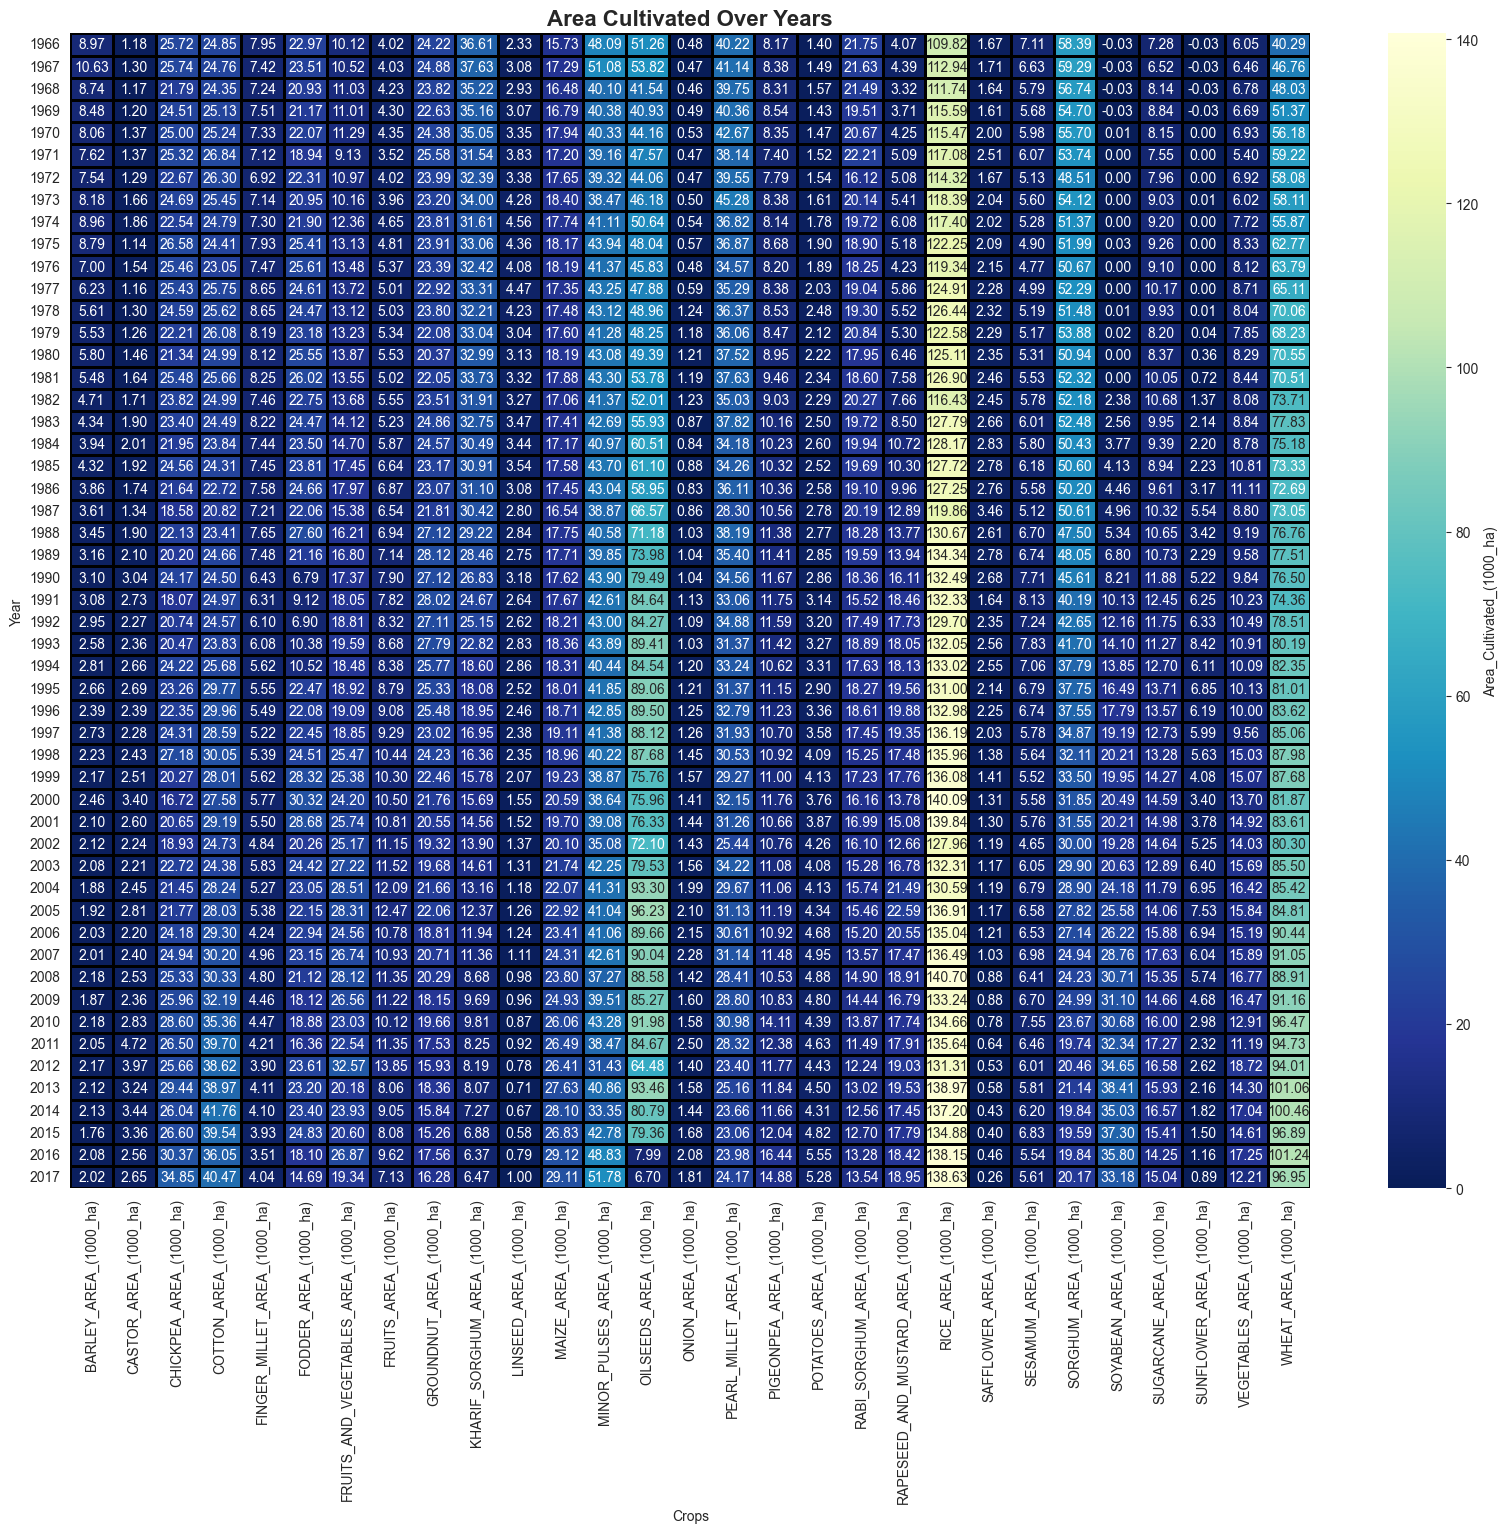

In [43]:
plt.figure(figsize=(20,15))
sns.set_style('whitegrid')
sns.heatmap(Area_df_year.pivot_table(index='Year', values=Area_columns),fmt='.2f',annot=True,cmap='YlGnBu_r',linewidths=1, linecolor='black',cbar_kws={'label': 'Area_Cultivated_(1000_ha)'})
plt.title('Area Cultivated Over Years', fontsize=16, fontweight='bold')
plt.xlabel('Crops')
plt.ylabel('Year')
plt.show()

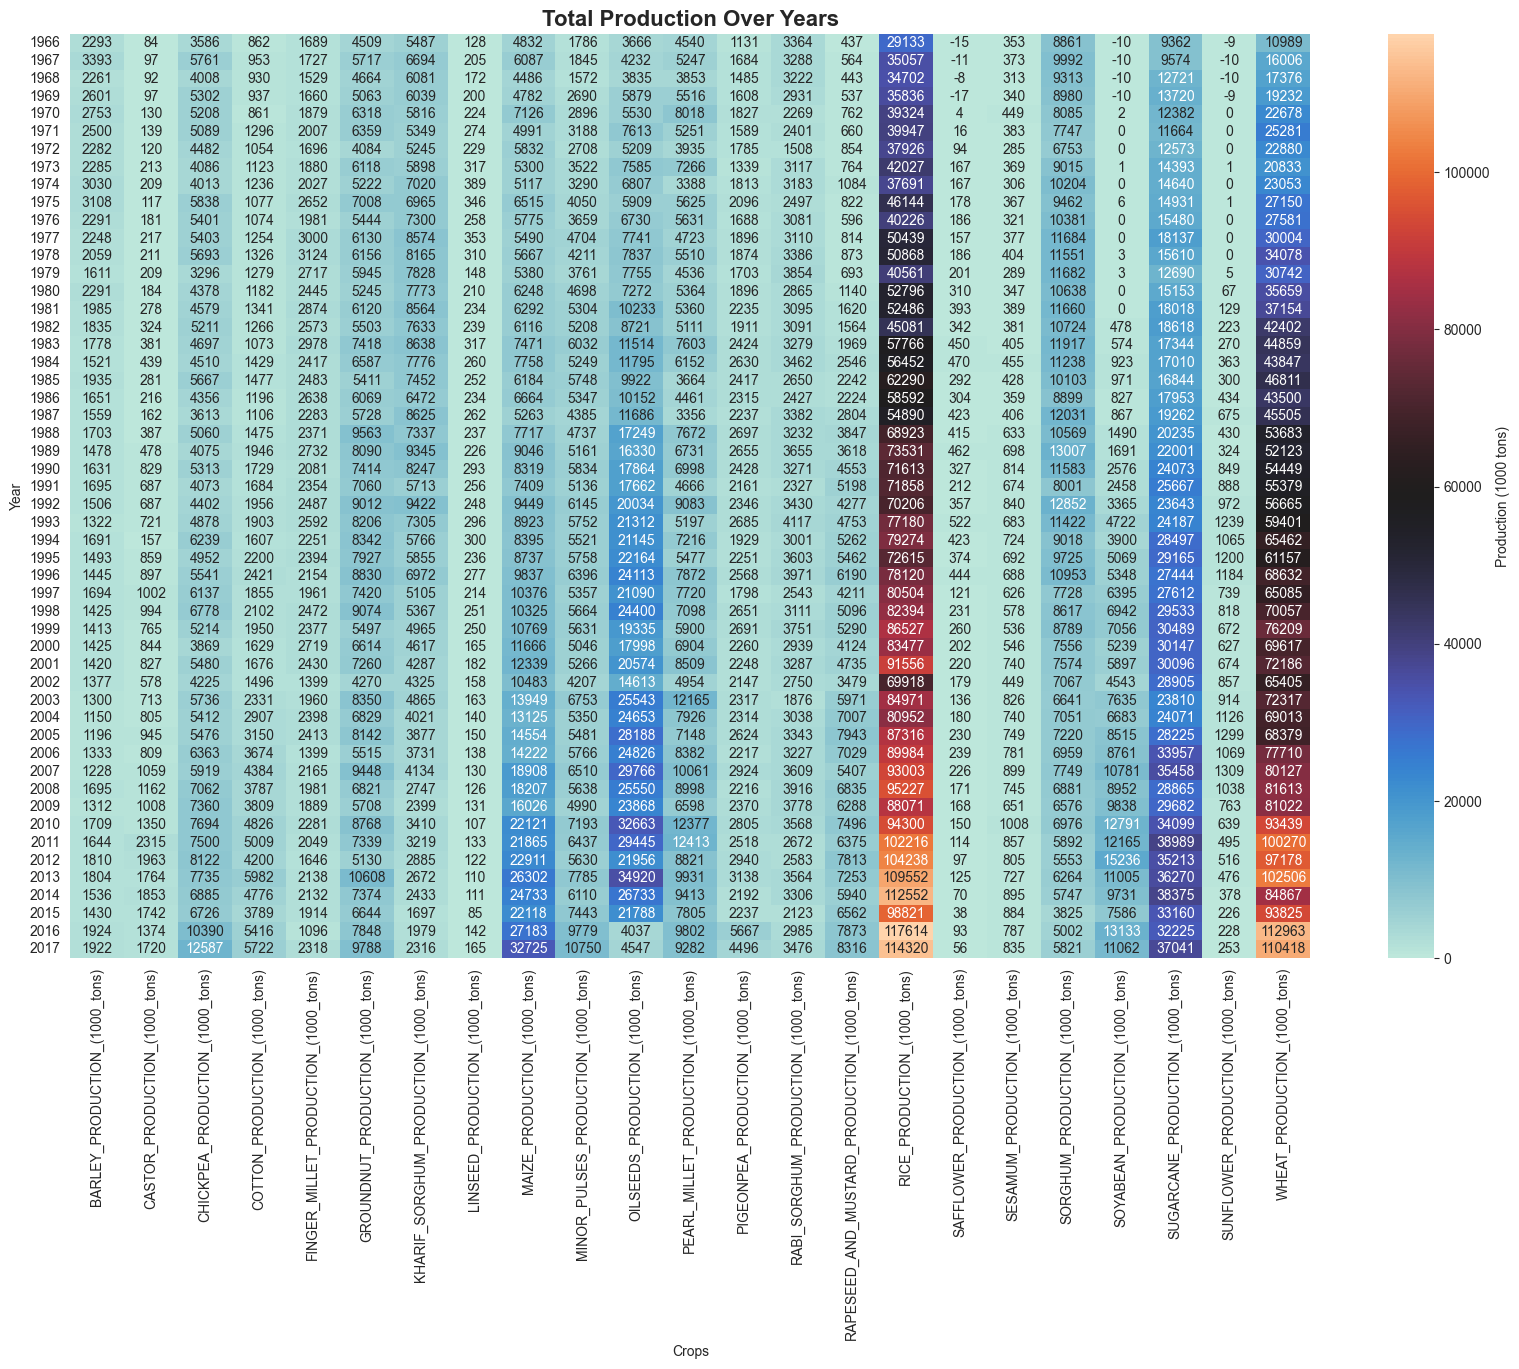

In [44]:
plt.figure(figsize=(20,12))
sns.heatmap(Crop_df[['Year', *Production_columns]].pivot_table(index='Year', values=Production_columns, aggfunc='sum'), annot=True, fmt='.0f', cmap='icefire', cbar_kws={'label': 'Production (1000 tons)'})
plt.title('Total Production Over Years', fontsize=16, fontweight='bold')
plt.xlabel('Crops')
plt.ylabel('Year')
plt.show()

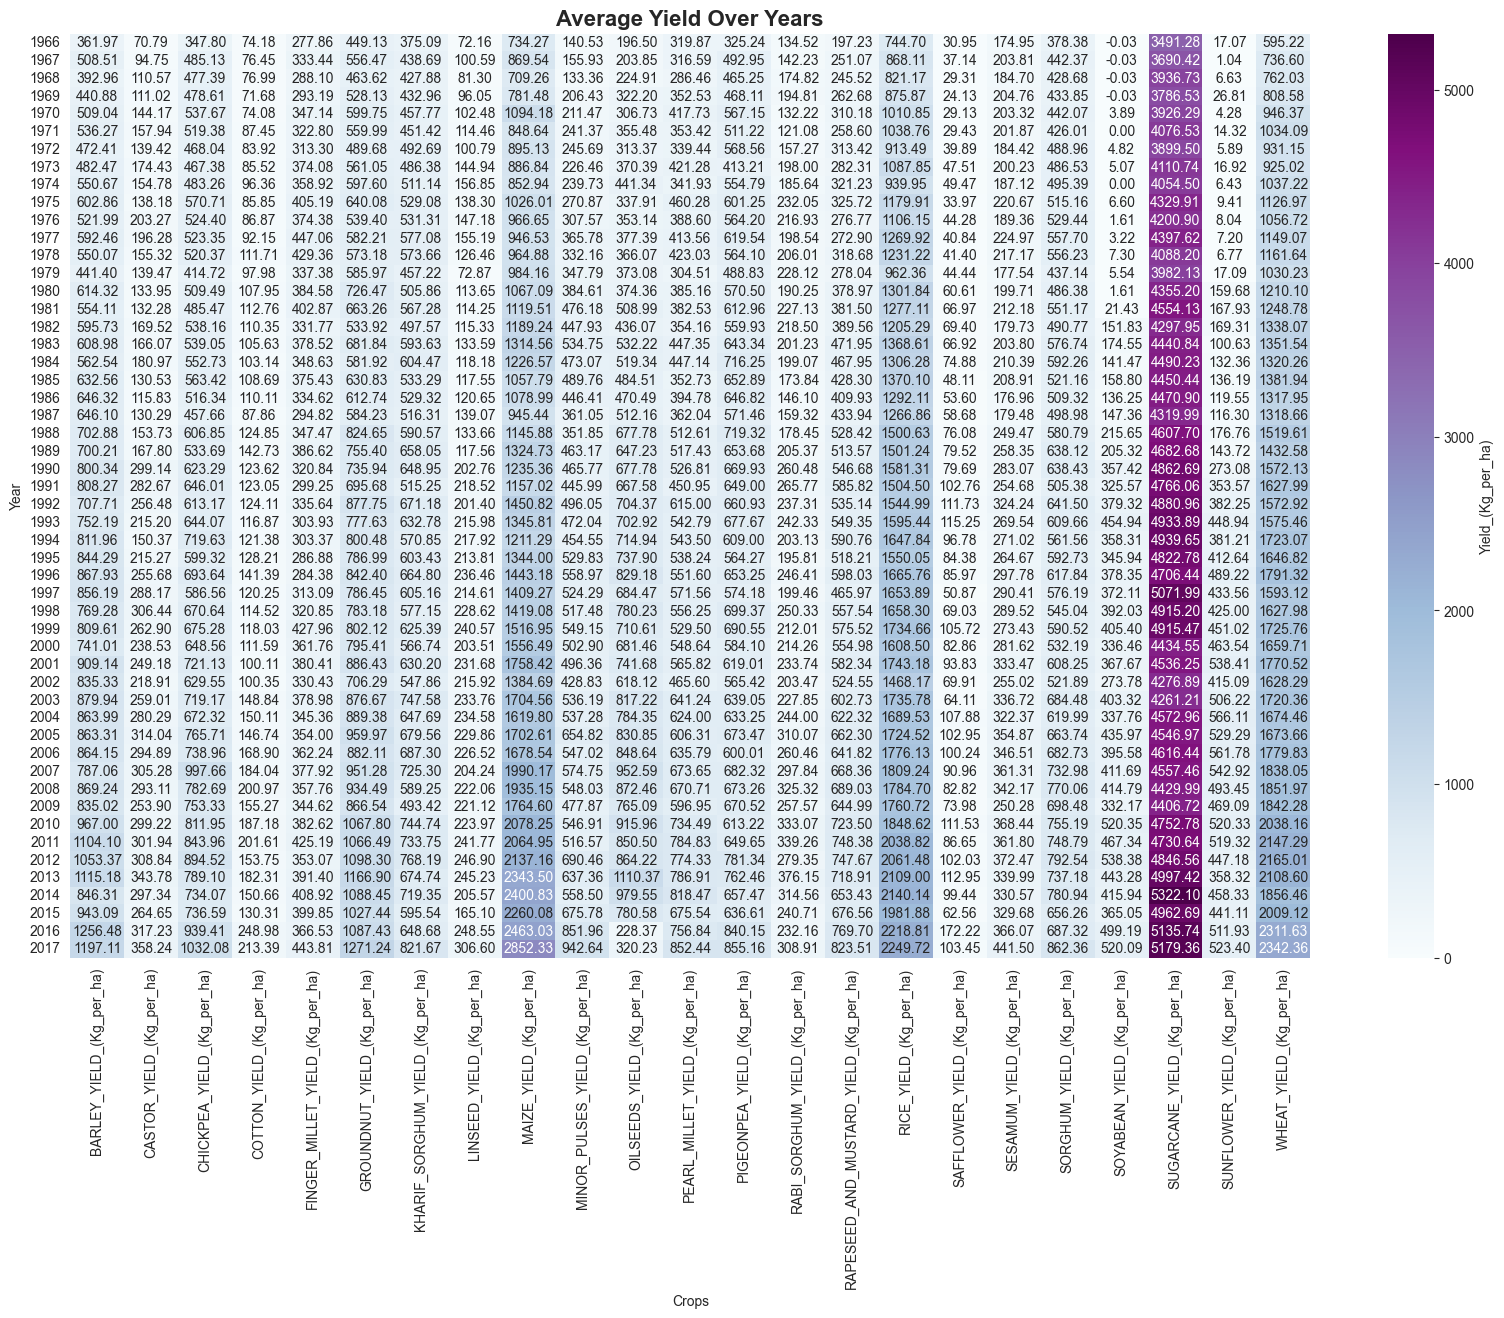

In [45]:
plt.figure(figsize=(20,12))
sns.heatmap(Avg_yeild_df, annot=True, fmt='.2f', cmap='BuPu', cbar_kws={'label': 'Yield_(Kg_per_ha)'})
plt.title('Average Yield Over Years', fontsize=16, fontweight='bold')
plt.xlabel('Crops')
plt.ylabel('Year')
plt.show()

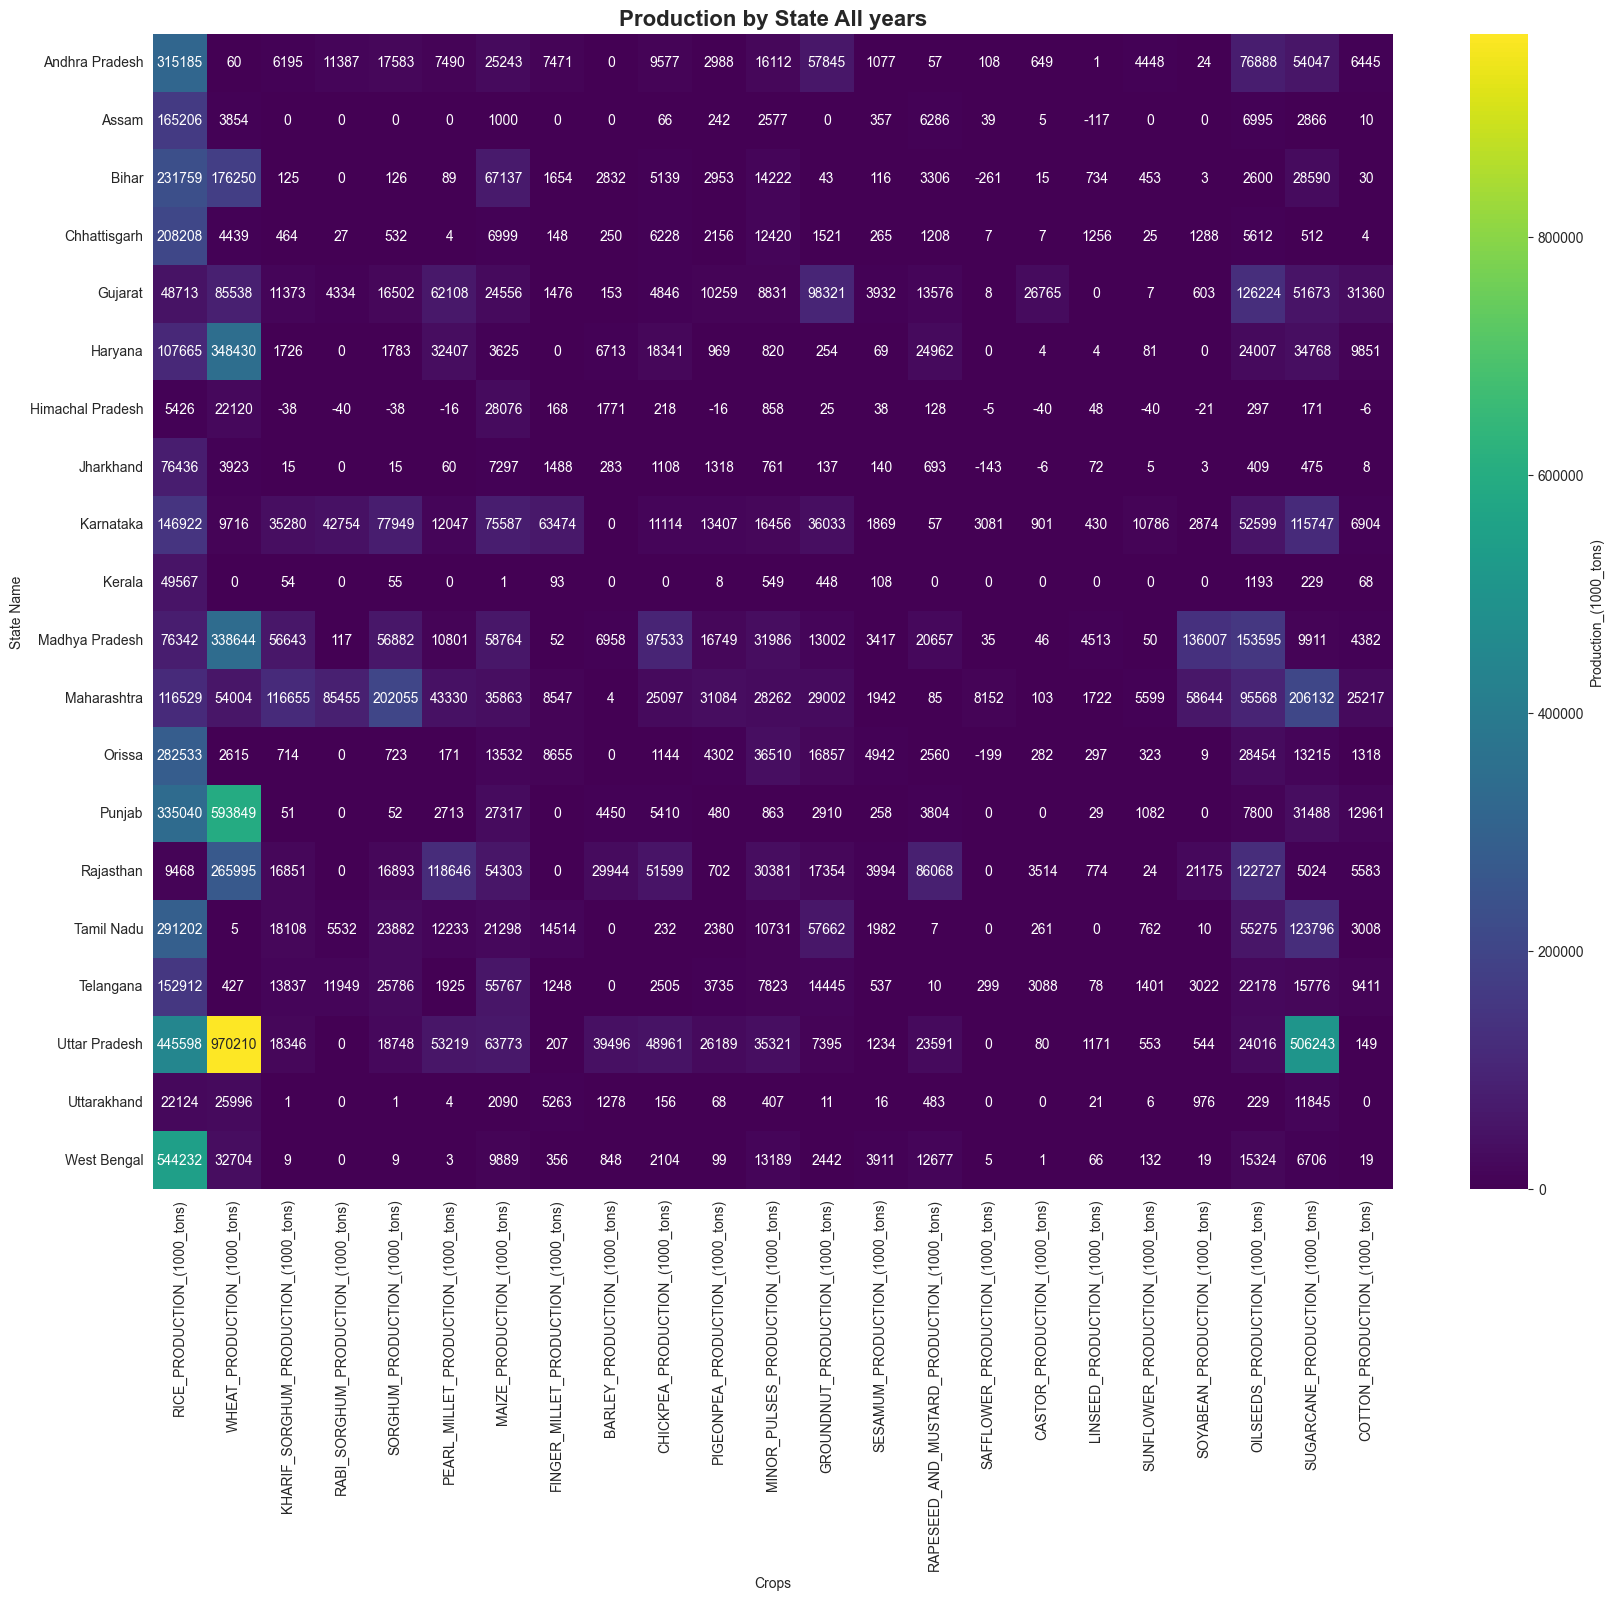

In [46]:
plt.figure(figsize=(20,15))
sns.heatmap(Crop_df[['State_Name',*Production_columns]].groupby('State_Name').sum(),annot=True, fmt='.0f', cmap='viridis', cbar_kws={'label': 'Production_(1000_tons)'})
plt.title('Production by State All years', fontsize=16, fontweight='bold')
plt.xlabel('Crops')
plt.ylabel('State Name')
plt.show()

### Average Cultivation Area of Crops in India

In [47]:
State_Area_df = Crop_df[['State_Name',*Area_columns]].groupby('State_Name').mean()
State_Area_df['Total_Area'] = State_Area_df[Area_columns].sum(axis=1)

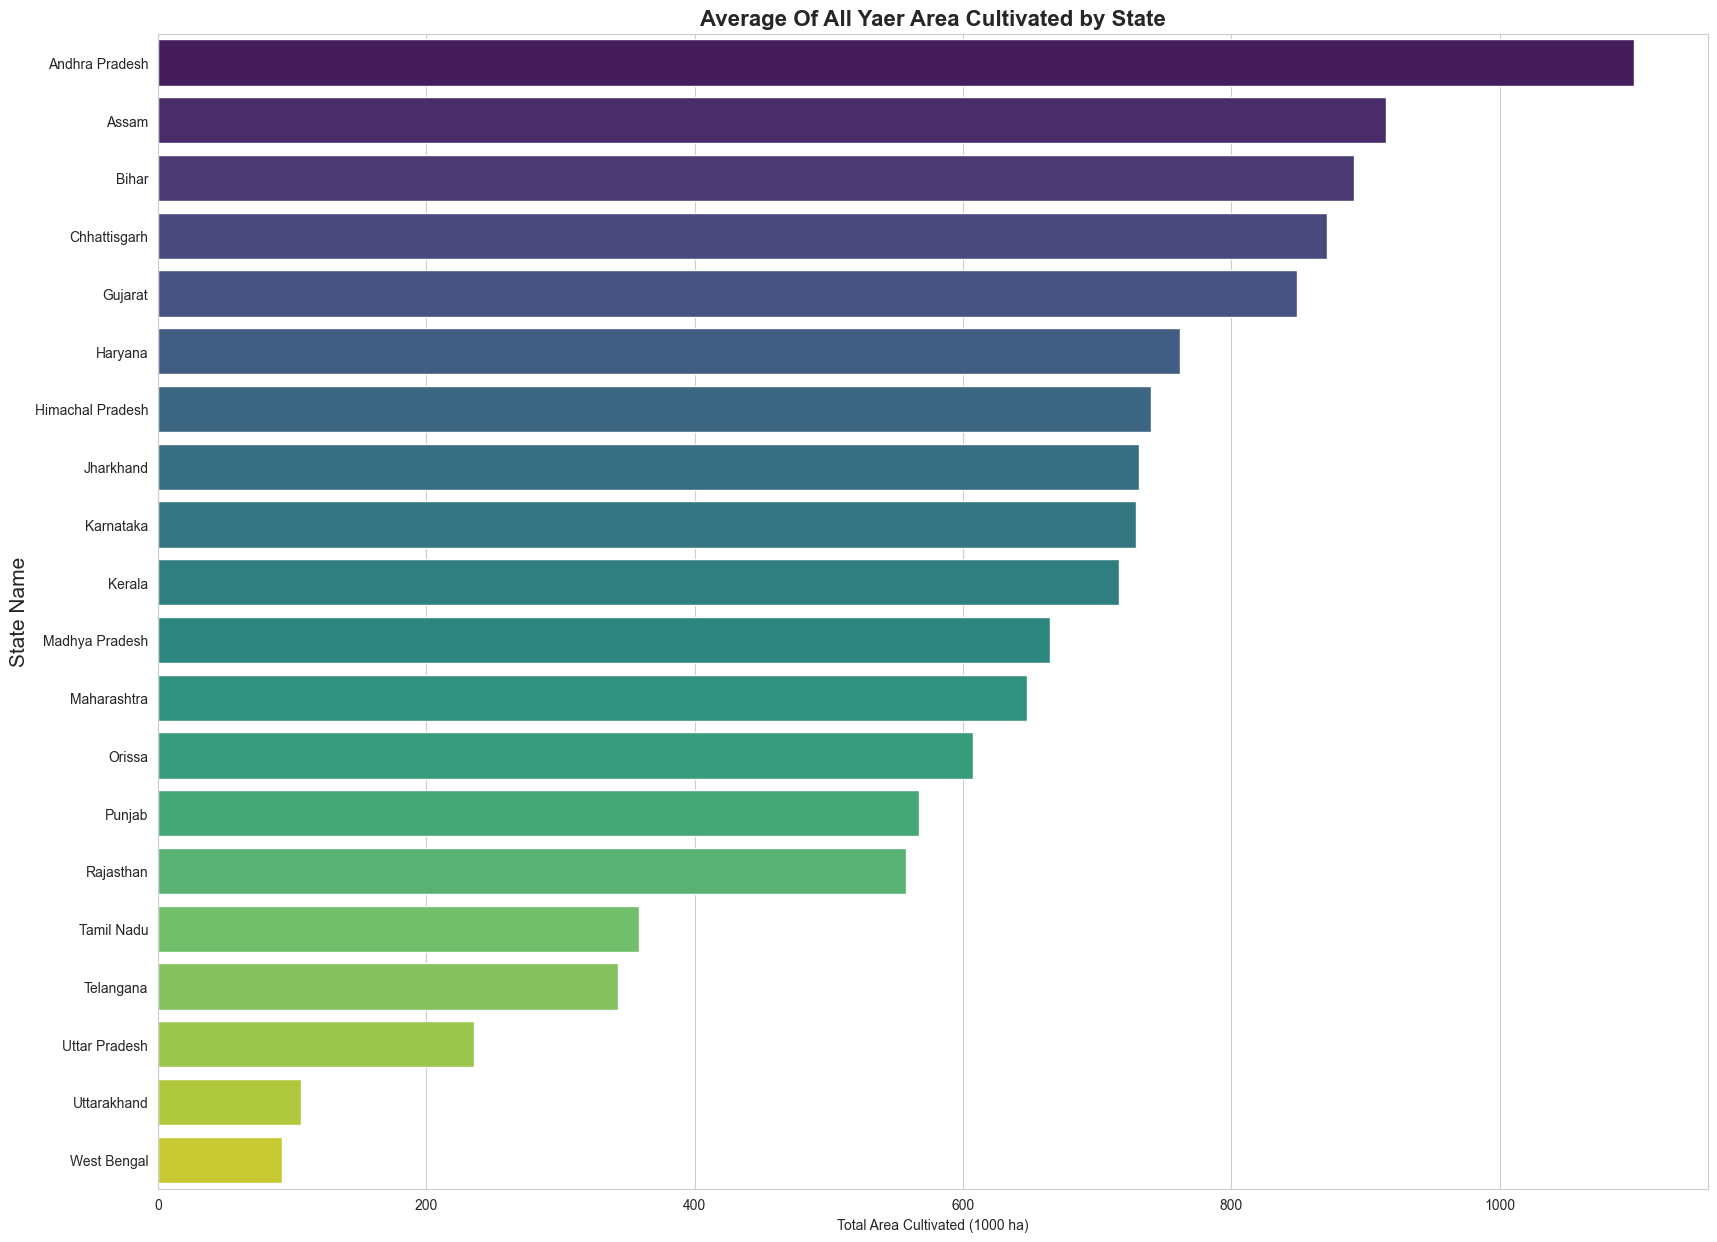

In [48]:
plt.figure(figsize=(20,15))
sns.set_style('whitegrid')
sns.barplot(x='Total_Area', y=State_Area_df.index, 
            data=State_Area_df[['Total_Area']].sort_values(by='Total_Area', ascending=False), 
            palette='viridis')
plt.title('Average Of All Yaer Area Cultivated by State', fontsize=16, fontweight='bold')
plt.xlabel('Total Area Cultivated (1000 ha)')
plt.ylabel('State Name', fontsize=15)
plt.show()

In [58]:
print(*[f"india_agri_data[{i}] +" for i in Production_columns])

india_agri_data[RICE_PRODUCTION_(1000_tons)] + india_agri_data[WHEAT_PRODUCTION_(1000_tons)] + india_agri_data[KHARIF_SORGHUM_PRODUCTION_(1000_tons)] + india_agri_data[RABI_SORGHUM_PRODUCTION_(1000_tons)] + india_agri_data[SORGHUM_PRODUCTION_(1000_tons)] + india_agri_data[PEARL_MILLET_PRODUCTION_(1000_tons)] + india_agri_data[MAIZE_PRODUCTION_(1000_tons)] + india_agri_data[FINGER_MILLET_PRODUCTION_(1000_tons)] + india_agri_data[BARLEY_PRODUCTION_(1000_tons)] + india_agri_data[CHICKPEA_PRODUCTION_(1000_tons)] + india_agri_data[PIGEONPEA_PRODUCTION_(1000_tons)] + india_agri_data[MINOR_PULSES_PRODUCTION_(1000_tons)] + india_agri_data[GROUNDNUT_PRODUCTION_(1000_tons)] + india_agri_data[SESAMUM_PRODUCTION_(1000_tons)] + india_agri_data[RAPESEED_AND_MUSTARD_PRODUCTION_(1000_tons)] + india_agri_data[SAFFLOWER_PRODUCTION_(1000_tons)] + india_agri_data[CASTOR_PRODUCTION_(1000_tons)] + india_agri_data[LINSEED_PRODUCTION_(1000_tons)] + india_agri_data[SUNFLOWER_PRODUCTION_(1000_tons)] + india_agr